---
---
## Trabajo Práctico 2 - Probabilidad Continua
---
---

Considerar 20 variables aleatorias que siguen una distribución normal estándar $(X_1, . . . , X_{20})$ y hacer el cambio de variables $Y_i = X^2_i$. Identificar que función de densidad de probabilidad siguen las nuevas variables $Y_i$. Construir una nueva variable aleatoria $Z=\sum^{20}_{i=1} Y_i$. A continuación simular las 20 variables $X_i$ y calcular el valor $Z$ correspondiente. Repetir este proceso 10.000 veces y hacer un histograma de frecuencias de $Z$. Comparar el histograma con una distribucion chi-cuadrado y otra normal con parametros apropiados.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [ ]:
#valores iniciales de cantidad de simulaciones y de variables
n_sim = 10000
n_var = 20

In [ ]:
#n_sim de las n_var variables, vectorizado
var_x = np.random.normal(size = (n_sim, n_var))
#elevamos al cuadrado
var_y = var_x**2
#definimos z sumando sobre el número de variables
var_z = var_y.sum(axis=1)

Vimos en clase que si $X_{i}\sim N\left(0,1\right),$ entonces la variable aleatoria $$Z=\sum_{i=1}^k X_{i}^{2}$$

cumple que $Z\sim\chi_{k}^{2}$, y que esa distribución tiene media $k$ y varianza $2k$. Esperamos entonces que nuestra variable $Z$ siga una distrubición $\chi_k^2$ con $k$ el número de variables sumadas.

Por otro lado, sabemos que las variables $Y_{i}\sim \chi_1^2$ tienen $E(Y_i)=1$ y $\text{Var}(Y_i) = 2$ (que son cantidades finitas) y son independientes, así que se cumplen las hipótesis del Teorema Central del Límite.

Entonces, esperamos que para $k$ grande, la distribución de $Z$ tienda a una $N(\mu,\sigma)$, con


*   $\mu = \sum_{i=1}^n E(Y_i) = n$,
*   $\sigma^2 = \sum_{i=1}^n \text{Var}(Y_i) = 2n$.


In [ ]:
#Definimos los parámetros para las distribuciones
mu = n_var
sigma = np.sqrt(2*mu)
k = n_var

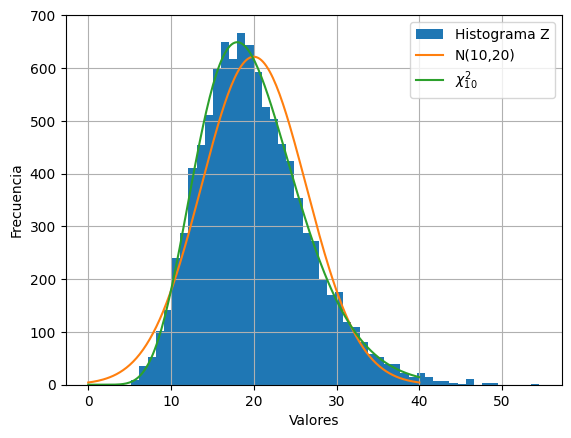

E(Z)= 20.068533592107553
Var(Z)= 41.67866915186402


In [ ]:
#gráfico
x = np.linspace(0,2*n_var, 10*n_var)
fig, ax1 = plt.subplots(1,1)
#histograma de la variable z
bins = ax1.hist(var_z, bins = 50, label = 'Histograma Z')
width = bins[1][2]-bins[1][1]

#graficamos las dos distribuciones, como piden histograma de frecuencias
#multiplicamos las pdfs por N y el ancho de cada bin
ax1.plot(x, len(var_z)*width*st.norm.pdf(x, loc=mu, scale=sigma), label = 'N(10,20)')
ax1.plot(x, len(var_z)*width*st.chi2.pdf(x,df=k), label ='$\chi^2_{10}$')

ax1.legend()
ax1.set_xlabel('Valores')
ax1.set_ylabel('Frecuencia')
ax1.grid(True)
plt.show()

print('E(Z)=',var_z.mean())
print('Var(Z)=',var_z.var())

Vemos que la distribución de los datos es muy similar a la PDF de $\chi_k^2$, y que esta se asemeja a la normal, aunque no coinciden exactamente.

Queremos ver qué pasa con la distribución cuando tomamos un número más grande de variables. Esperamos que las dos distribuciones se asemejen aún más.


In [ ]:
#Para ver como cambia la distribución de los datos al aumentar N, definimos una
#función repitiendo lo anterior

def dist(n_var = 20, n_sim = 10000, bins = 50):

  var_x = np.random.normal(size = (n_sim, n_var))

  var_y = var_x**2

  var_z = var_y.sum(axis=1)

  mu = n_var
  sigma = np.sqrt(2*mu)


  x = np.linspace(0,mu+5*sigma, 1000)
  fig, ax1 = plt.subplots(1,1)

  bins = ax1.hist(var_z, bins = 50, label = 'Histograma Z')
  width = bins[1][2]-bins[1][1]
  ax1.plot(x, len(var_z)*width*st.norm.pdf(x, loc=mu, scale=sigma), label = 'N(100,200)')
  ax1.plot(x, len(var_z)*width*st.chi2.pdf(x,df=n_var), label ='$\chi^2_{100}$')

  ax1.legend()
  ax1.set_title(f'Distribucion con {n_var} variables')
  ax1.set_xlabel('Valores')
  ax1.set_ylabel('Probabilidad')
  ax1.grid(True)

  #Imprimimos media y varianza de los datos para comparar con las PDF
  print('E(Z)=',var_z.mean())
  print('Var(Z)=',var_z.var())
  return

E(Z)= 99.9221932312805
Var(Z)= 197.5096105405329


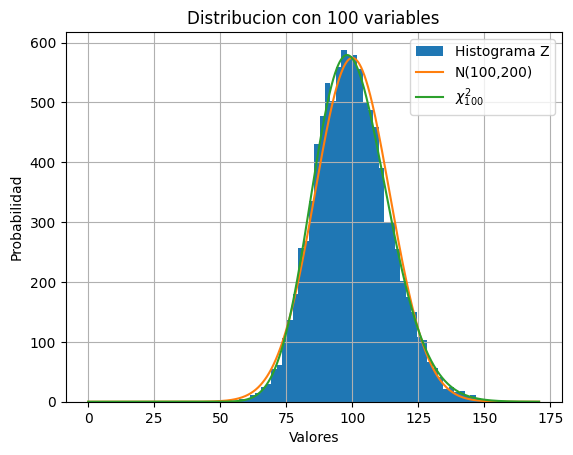

In [ ]:
#Vemos que pasa si tomamos 100 variables independientes
dist(100)

Como era esperado por el teorema central del límite, se puede ver que a medida que aumentamos el número de variables $k$, las dos distribuciones se asemejan más (podemos ver que las medias y varianzas están más cerca, y que los gráficos se solapan más).

##Conclusiones

En resumen, verificamos que elevar al cuadrado $k$ variables aleatorias independientes y sumarlas da una nueva variable aleatoria que sigue una distribución $\chi_k^2$, y que esa distribución cumple el Teorema Central del Límite.